In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras

In [5]:
(x_train,y_train),(x_test,y_test) = keras.datasets.mnist.load_data()

# about dataset

In [6]:
#3D variable
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [7]:
#First element which is a 28x28 matrix
print(x_train[0].shape)
x_train[0]

(28, 28)


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [8]:
# output data
print(y_train.shape)
print(y_train[0:5])

(60000,)
[5 0 4 1 9]


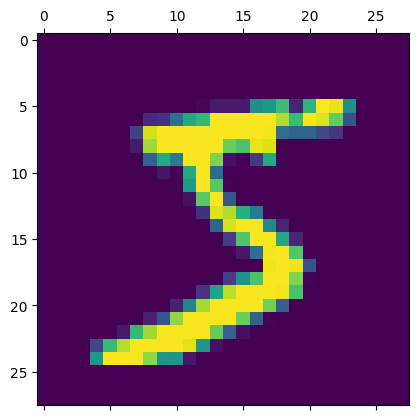

In [9]:
#visualizing the elements
plt.matshow(x_train[0])
plt.show()


# model preprocessing

In [10]:
#flattening the variables (3D to 2D)
x_train_flattened=x_train.reshape(len(x_train),28*28)
x_test_flattened=x_test.reshape(len(x_test),28*28)
print(x_train_flattened.shape)

(60000, 784)


In [11]:
x_train_scaled = x_train_flattened / 255.0 #here 255 is because the pixel values range from 0 to 255
x_test_scaled = x_test_flattened / 255.0

# model creation (ANN - Artificial Neural Network)

In [12]:
model = keras.Sequential()
model.add(keras.layers.Dense(10,input_shape=(784,),activation='sigmoid'))
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

d:\data science 2025\git_repository\data-science-project-\digit recognization\demo\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.fit(x_train_scaled,y_train,epochs=5)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - accuracy: 0.8794 - loss: 0.4620
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9156 - loss: 0.3034
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9212 - loss: 0.2831
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9235 - loss: 0.2729
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9255 - loss: 0.2666


In [14]:
model.evaluate(x_test_scaled, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9241 - loss: 0.2715


[0.2715285122394562, 0.9240999817848206]

In [15]:
y_pred=model.predict(x_test_scaled)
y_pred.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(10000, 10)

In [16]:
y_pred[0]

array([3.26316766e-02, 6.58126169e-07, 6.91527873e-02, 9.73956048e-01,
       3.17443232e-03, 1.06397122e-01, 1.09015571e-06, 9.99775529e-01,
       1.00256056e-01, 6.67798519e-01], dtype=float32)

In [17]:
# In the output there are ten values (probabilities) for each image those are called ten neurons in output layer we pick the highest probability one
y_pred_int = np.argmax(y_pred,axis=1)# runs column wise and returns index of max value 
print(y_pred_int)

[7 2 1 ... 4 5 6]


Predicted digit y_pred_int: 7
Actual digit y_test_int: 7


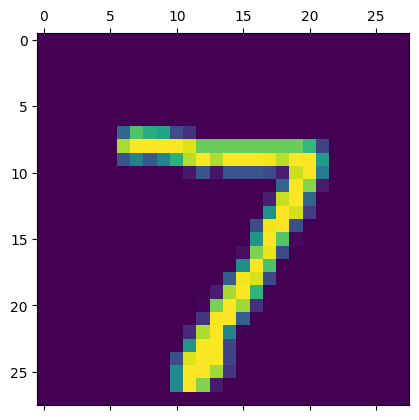

In [18]:
#visualizing the test data
plt.matshow(x_test[0])
print("Predicted digit y_pred_int:", y_pred_int[0])
print("Actual digit y_test_int:", y_test[0])
plt.show()

# Analysis of prediction values

In [19]:
cm=tf.math.confusion_matrix(y_test,y_pred_int)
print(cm)

tf.Tensor(
[[ 964    0    1    2    0    4    6    2    1    0]
 [   0 1112    3    2    0    1    4    2   11    0]
 [   8   10  917   24    9    3   12    9   36    4]
 [   3    0   14  941    1   17    2    8   17    7]
 [   2    1    2    2  923    0   11    4   10   27]
 [  12    3    4   40   10  771   17    6   24    5]
 [  14    3    7    1    8   11  911    2    1    0]
 [   1    9   21   11   10    0    0  940    1   35]
 [   9    9    5   38    9   27    9   10  851    7]
 [  11    7    1   14   35    6    0   20    4  911]], shape=(10, 10), dtype=int32)


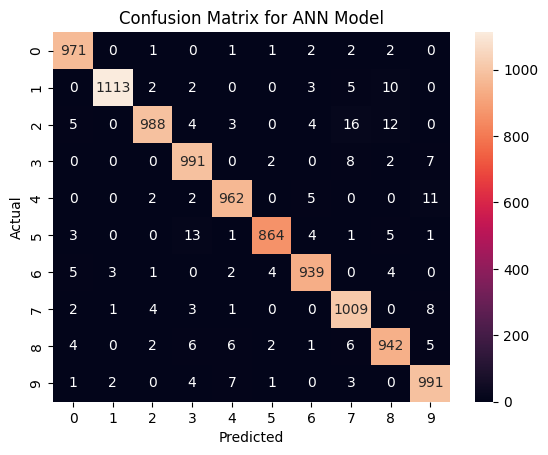

In [33]:
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for ANN Model')
plt.show()

## DNN-deep neural network to improve the model performance
# Hidden layers(deep learning)

In [21]:
model2=keras.Sequential()
model2.add(keras.layers.Dense(100,input_shape=(784,),activation='relu')) #first hidden layer output 100 neurons
model2.add(keras.layers.Dense(10,activation='sigmoid'))#output layer 10 neurons
model2.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

d:\data science 2025\git_repository\data-science-project-\digit recognization\demo\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model2.evaluate(x_test_scaled, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1048 - loss: 2.4130


[2.41304087638855, 0.10480000078678131]

In [23]:
model2.fit(x_train_scaled,y_train,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.9243 - loss: 0.2676
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9643 - loss: 0.1203
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9747 - loss: 0.0844
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9806 - loss: 0.0637
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9846 - loss: 0.0505


In [24]:
y_pred2=model2.predict(x_test_scaled)
y_pred2[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([1.2786972e-02, 1.7665855e-04, 2.4845649e-02, 7.0934498e-01,
       1.8275945e-06, 1.7540377e-02, 1.6852703e-06, 9.9998629e-01,
       1.8540060e-02, 7.8711867e-02], dtype=float32)

In [25]:
#choosing the max probability one from y_pred
y_pred2_int=np.argmax(y_pred2,axis=1)
y_pred2_int[0]

np.int64(7)

Predicted digit y_pred2_int: 7
Actual digit y_test_int: 7


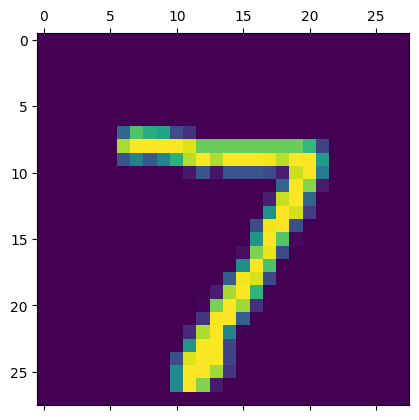

In [28]:
#visualizing the test data for model with hidden layer
plt.matshow(x_test[0])
print("Predicted digit y_pred2_int:", y_pred2_int[0])
print("Actual digit y_test_int:", y_test[0])
plt.show()

In [29]:
cm=tf.math.confusion_matrix(y_test, y_pred2_int)
print(cm)

tf.Tensor(
[[ 971    0    1    0    1    1    2    2    2    0]
 [   0 1113    2    2    0    0    3    5   10    0]
 [   5    0  988    4    3    0    4   16   12    0]
 [   0    0    0  991    0    2    0    8    2    7]
 [   0    0    2    2  962    0    5    0    0   11]
 [   3    0    0   13    1  864    4    1    5    1]
 [   5    3    1    0    2    4  939    0    4    0]
 [   2    1    4    3    1    0    0 1009    0    8]
 [   4    0    2    6    6    2    1    6  942    5]
 [   1    2    0    4    7    1    0    3    0  991]], shape=(10, 10), dtype=int32)


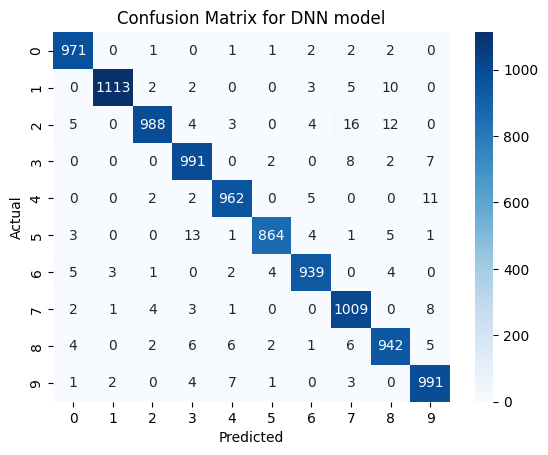

In [34]:
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix for DNN model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Saving the model for backend use


In [35]:
import pickle
with open('model1.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('model2.pkl', 'wb') as f:
    pickle.dump(model2, f)